In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#ESSENTIALS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

#MODELS
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

#TOOLS
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report, average_precision_score
from scipy.stats import ks_2samp

In [3]:
# read data
X_train = pd.read_csv('/content/drive/MyDrive/Research/Default_Prediction/Source Code/data/model_input/X_train.csv')
y_train = pd.read_csv('/content/drive/MyDrive/Research/Default_Prediction/Source Code/data/model_input/y_train.csv')
X_test = pd.read_csv('/content/drive/MyDrive/Research/Default_Prediction/Source Code/data/model_input/X_test.csv')
y_test = pd.read_csv('/content/drive/MyDrive/Research/Default_Prediction/Source Code/data/model_input/y_test.csv')

# reshape y_train and y_test to 1D arrays
X_train = X_train.drop(columns=['UserName'])
X_test = X_test.drop(columns=['UserName'])
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [ ]:
def ks_statistic(y_true, y_proba):
    """Kolmogorov-Smirnov statistic: max separation between the cumulative
    distributions of predicted probabilities for the positive vs negative class."""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    pos_scores = y_proba[y_true == 1]
    neg_scores = y_proba[y_true == 0]
    return ks_2samp(pos_scores, neg_scores).statistic


def train_and_evaluate(models, X_train, y_train, X_test, y_test, scoring='f1'):
    best_models = {}
    results = {}

    for name, (model, params) in models.items():
        print(f"Training {name}...")

        grid_search = GridSearchCV(
            estimator=model,
            param_grid=params,
            cv=5,
            scoring=scoring,
            n_jobs=-1
        )

        # --- Training time (includes GridSearchCV over all folds/candidates) ---
        train_start = time.time()
        grid_search.fit(X_train, y_train)
        train_time = time.time() - train_start

        best_model = grid_search.best_estimator_
        best_models[name] = best_model

        # --- Inference time on the test set ---
        infer_start = time.time()
        y_pred = best_model.predict(X_test)
        y_proba = best_model.predict_proba(X_test)[:, 1]
        infer_time = time.time() - infer_start

        n_test = len(X_test)
        infer_time_per_sample_ms = (infer_time / n_test) * 1000

        metrics = {
            "AUC-ROC": roc_auc_score(y_test, y_proba),
            "AUC-PR": average_precision_score(y_test, y_proba),
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1 Score": f1_score(y_test, y_pred, zero_division=0),
            "KS Statistic": ks_statistic(y_test, y_proba),
            "Train Time (s)": train_time,
            "Inference Time (s)": infer_time,
            "Inference Time per Sample (ms)": infer_time_per_sample_ms,
            "Scoring Metric": scoring
        }

        results[name] = metrics

        print(f"Best params for {name}: {grid_search.best_params_}")
        print(
            f"Metrics: "
            f"AUC-ROC={metrics['AUC-ROC']:.4f}, "
            f"AUC-PR={metrics['AUC-PR']:.4f}, "
            f"Acc={metrics['Accuracy']:.4f}, "
            f"Prec={metrics['Precision']:.4f}, "
            f"Rec={metrics['Recall']:.4f}, "
            f"F1={metrics['F1 Score']:.4f}, "
            f"KS={metrics['KS Statistic']:.4f}, "
            f"TrainTime={metrics['Train Time (s)']:.2f}s, "
            f"InferTime={metrics['Inference Time (s)']:.4f}s "
            f"({metrics['Inference Time per Sample (ms)']:.4f} ms/sample)\n",
        )

    return best_models, results


In [8]:
def plot_roc_curves(best_models, X_test, y_test):
    plt.figure(figsize=(10, 6))

    for name, model in best_models.items():
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc_score = roc_auc_score(y_test, y_proba)

        plt.plot(
            fpr,
            tpr,
            label=f"{name} (AUC = {auc_score:.2f})"
        )

    plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

Training Logistic Regression...
Best params for Logistic Regression: {'C': 0.01, 'solver': 'lbfgs'}
Metrics: AUC-ROC=0.5127, AUC-PR=0.7233, Acc=0.7197, Prec=0.7297, Rec=0.9673, F1=0.8318, KS=0.0673, TrainTime=34.33s, InferTime=0.0362s (0.0019 ms/sample)

Training XGBoost...
Best params for XGBoost: {'learning_rate': 0.01, 'n_estimators': 50}
Metrics: AUC-ROC=0.6185, AUC-PR=0.7833, Acc=0.7221, Prec=0.7286, Rec=0.9757, F1=0.8342, KS=0.1838, TrainTime=91.74s, InferTime=0.0732s (0.0038 ms/sample)



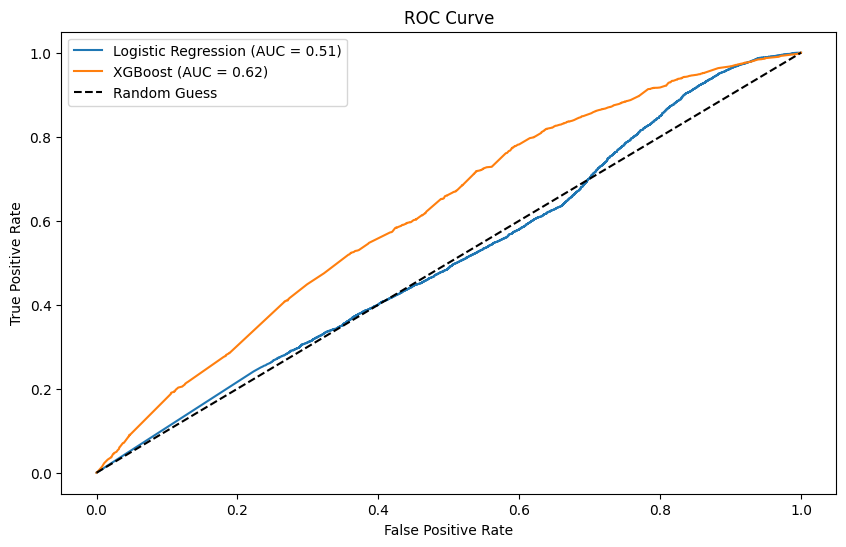

In [9]:
# Define models and hyperparameters
models = {
    "Logistic Regression": (
        LogisticRegression(),
         {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
        }),
    "XGBoost": (
        XGBClassifier(),
         {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        })
}

best_models, results = train_and_evaluate(
    models,
    X_train,
    y_train,
    X_test,
    y_test
)

plot_roc_curves(best_models, X_test, y_test)


In [17]:
results

{'Logistic Regression': {'AUC-ROC': np.float64(0.5126525694649874),
  'AUC-PR': np.float64(0.7232792671253643),
  'Accuracy': 0.7196819085487077,
  'Precision': 0.7296702086659693,
  'Recall': 0.9673016568133713,
  'F1 Score': 0.8318478533768516,
  'KS Statistic': np.float64(0.06727506287357235),
  'Train Time (s)': 34.32924818992615,
  'Inference Time (s)': 0.03616595268249512,
  'Inference Time per Sample (ms)': 0.0018921184829180243},
 'XGBoost': {'AUC-ROC': np.float64(0.6185356335533889),
  'AUC-PR': np.float64(0.7833095586130414),
  'Accuracy': 0.7220885215025635,
  'Precision': 0.7286204829127377,
  'Recall': 0.9756952047295818,
  'F1 Score': 0.8342486270594108,
  'KS Statistic': np.float64(0.18381747908840296),
  'Train Time (s)': 91.7417004108429,
  'Inference Time (s)': 0.07323193550109863,
  'Inference Time per Sample (ms)': 0.003831324448106029}}

In [23]:
file_path = r"/content/drive/MyDrive/Research/Default_Prediction/Source Code/notebook/2. model/results.txt"
with open(file_path, "w", encoding="utf-8") as f:
    f.write("Model Evaluation Results:\n")
    f.write(time.strftime("%Y-%m-%d %H:%M:%S", time.localtime()) + "\n\n")

    for name, metrics in results.items():
        # Lấy best params nếu có lưu trong best_models, nếu không thì ghi N/A
        best_params = (
            best_models[name].get_params()
            if "best_models" in locals() and name in best_models
            else "N/A"
        )

        print(f"Best params for {name}: {best_params}", file=f)
        print(
            f"Metrics: "
            f"AUC-ROC={metrics['AUC-ROC']:.4f}, "
            f"AUC-PR={metrics['AUC-PR']:.4f}, "
            f"Acc={metrics['Accuracy']:.4f}, "
            f"Prec={metrics['Precision']:.4f}, "
            f"Rec={metrics['Recall']:.4f}, "
            f"F1={metrics['F1 Score']:.4f}, "
            f"KS={metrics['KS Statistic']:.4f}, "
            f"TrainTime={metrics['Train Time (s)']:.2f}s, "
            f"InferTime={metrics['Inference Time (s)']:.4f}s "
            f"({metrics['Inference Time per Sample (ms)']:.4f} ms/sample)\n",
            file=f,
        )

    f.flush()